## AutoML

Tried Databricks but it did not have the feature for AutoML available for my account type. So, implementing the AutoML process here locally using PyCaret. H2O also works but is not recommended here as the dataset is relativly smaller.

In [18]:
# --- Core data handling ---
import os
import random
import time
import warnings

import numpy as np
import pandas as pd

from pycaret.classification import create_model
from pycaret.classification import tune_model

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.classification import plot_model

# --- MLOps platform: experiment tracking ---
import mlflow

# --- Chosen AutoML platform: PyCaret (classification) ---
from pycaret.classification import (
    setup as pycaret_setup,
    compare_models,
    pull,
    predict_model,
    finalize_model,
    save_model,
)

warnings.filterwarnings("ignore")

# --- Reproducibility ---
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)


Random seed: 42


In [2]:
DATA_PATH = os.path.join("..", "data", "processed", "diabetic_data_features.csv")

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {df_raw.shape[0]} rows and {df_raw.shape[1]} columns")

# Same feature set as the XGBoost baseline (notebooks/final-group3-en.ipynb),
# so the AutoML leaderboard is directly comparable to it later.
FEATURE_COLS = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'admission_type_id',
    'discharge_disposition_id', 'admission_source_id',
    'diag_1_category', 'medical_specialty_grouped', 'race_white',
    'gender', 'age_ordinal',
]
TARGET_COL = 'readmitted_binary'

df_model = df_raw[FEATURE_COLS + [TARGET_COL]].copy()

print("\nColumns ready for AutoML:", df_model.shape[1])
print("\nMissing values:")
print(df_model.isnull().sum())
print(f"\nTarget ('{TARGET_COL}') distribution:")
print(df_model[TARGET_COL].value_counts(normalize=True).round(3))

assert df_model.isnull().sum().sum() == 0, "Dataset is not AutoML-ready: missing values remain."
print("\nDataset is AutoML-ready.")


Loaded 69987 rows and 53 columns

Columns ready for AutoML: 17

Missing values:
time_in_hospital             0
num_lab_procedures           0
num_procedures               0
num_medications              0
number_outpatient            0
number_emergency             0
number_inpatient             0
number_diagnoses             0
admission_type_id            0
discharge_disposition_id     0
admission_source_id          0
diag_1_category              0
medical_specialty_grouped    0
race_white                   0
gender                       0
age_ordinal                  0
readmitted_binary            0
dtype: int64

Target ('readmitted_binary') distribution:
readmitted_binary
0    0.593
1    0.407
Name: proportion, dtype: float64

Dataset is AutoML-ready.


### MLflow Configuration

In [3]:
# --- MLflow tracking configuration (local SQLite, same pattern as Assignment #3) ---
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

EXPERIMENT_NAME = "diabetes-readmission-automl-pycaret"
mlflow.set_experiment(EXPERIMENT_NAME)

# --- PyCaret AutoML run configuration ---
# diag_1_category, medical_specialty_grouped, gender are string columns -> categorical.
# Everything else is already integer-coded (IDs, counts, or pre-encoded ordinal/binary
# features), matching how the XGBoost baseline consumed them directly as numeric.
NUMERIC_FEATURES = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'admission_type_id',
    'discharge_disposition_id', 'admission_source_id',
    'race_white', 'age_ordinal',
]
CATEGORICAL_FEATURES = ['diag_1_category', 'medical_specialty_grouped', 'gender']

pycaret_setup(
    data=df_model,
    target=TARGET_COL,
    train_size=0.8,               # matches the baseline's 80/20 split
    session_id=RANDOM_SEED,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    fold=10,                      # 10-fold cross-validation on the training split
    fold_strategy="stratifiedkfold",
    log_experiment=False,         # logging done manually after compare_models() -
    experiment_name=EXPERIMENT_NAME,  # see note if this changes once we check mlflow version
    log_plots=False,
    verbose=True,
)

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"Tracking URI:        {mlflow.get_tracking_uri()}")
print(f"Experiment name:     {experiment.name}")
print(f"Target variable:     {TARGET_COL}")
print(f"Train/test split:    80/20, session_id={RANDOM_SEED}")
print(f"Validation strategy: 10-fold stratified cross-validation")


,Description,Value
0,Session id,42
1,Target,readmitted_binary
2,Target type,Binary
3,Original data shape,"(69987, 17)"
4,Transformed data shape,"(69987, 36)"
5,Transformed train set shape,"(55989, 36)"
6,Transformed test set shape,"(13998, 36)"
7,Numeric features,13
8,Categorical features,3
9,Preprocess,True


Tracking URI:        sqlite:///../mlflow.db
Experiment name:     diabetes-readmission-automl-pycaret
Target variable:     readmitted_binary
Train/test split:    80/20, session_id=42
Validation strategy: 10-fold stratified cross-validation


### Running AutoML process

In [4]:
PRIMARY_METRIC = "AUC"  # PyCaret's classification metric name for AUC-ROC

start_time = time.time()
best_model_all_features = compare_models(sort=PRIMARY_METRIC)
elapsed_all_features = time.time() - start_time

leaderboard = pull()

print(f"compare_models() finished in {elapsed_all_features:.1f}s")
print(f"Primary validation metric (leaderboard sort order): {PRIMARY_METRIC}")
print(f"Candidate models evaluated: {leaderboard.shape[0]}")
print(f"Best model (leader): {leaderboard.iloc[0]['Model']}")

# --- Manually log every candidate model to MLflow ---
metric_cols = [c for c in leaderboard.columns if c not in ("Model", "TT (Sec)")]

for model_id, row in leaderboard.iterrows():
    with mlflow.start_run(run_name=f"pycaret_{model_id}"):
        mlflow.set_tags({"platform": "PyCaret", "target": TARGET_COL})
        mlflow.log_param("model_id", model_id)
        mlflow.log_param("model_name", row["Model"])
        for metric in metric_cols:
            value = row[metric]
            if isinstance(value, (int, float)):
                mlflow.log_metric(metric.replace(" ", "_"), value)
        if "TT (Sec)" in row:
            mlflow.log_metric("fit_time_sec", row["TT (Sec)"])

print(f"\nLogged {leaderboard.shape[0]} candidate models to MLflow experiment '{EXPERIMENT_NAME}'")
leaderboard


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,19:38:09
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.6361,0.6574,0.3401,0.5931,0.4323,0.1925,0.2086,5.0240
lightgbm,Light Gradient Boosting Machine,0.6350,0.6536,0.3239,0.5957,0.4196,0.1860,0.2044,0.7410
gbc,Gradient Boosting Classifier,0.6292,0.6477,0.2619,0.6037,0.3652,0.1576,0.1851,1.6930
xgboost,Extreme Gradient Boosting,0.6287,0.6462,0.3556,0.5712,0.4383,0.1828,0.1943,0.2810
ada,Ada Boost Classifier,0.6259,0.6373,0.2686,0.5897,0.3691,0.1531,0.1771,0.5110
rf,Random Forest Classifier,0.6193,0.6319,0.3535,0.5510,0.4306,0.1647,0.1739,1.8360
lr,Logistic Regression,0.6220,0.6287,0.2262,0.5945,0.3276,0.1331,0.1632,1.1350
ridge,Ridge Classifier,0.6213,0.6280,0.2120,0.5995,0.3131,0.1275,0.1604,0.1010
lda,Linear Discriminant Analysis,0.6216,0.6280,0.2169,0.5980,0.3183,0.1296,0.1615,0.1370
et,Extra Trees Classifier,0.6073,0.6158,0.3596,0.5264,0.4272,0.1443,0.1504,2.1960


compare_models() finished in 172.1s
Primary validation metric (leaderboard sort order): AUC
Candidate models evaluated: 16
Best model (leader): CatBoost Classifier

Logged 16 candidate models to MLflow experiment 'diabetes-readmission-automl-pycaret'


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.6361,0.6574,0.3401,0.5931,0.4323,0.1925,0.2086,5.024
lightgbm,Light Gradient Boosting Machine,0.6350,0.6536,0.3239,0.5957,0.4196,0.1860,0.2044,0.741
gbc,Gradient Boosting Classifier,0.6292,0.6477,0.2619,0.6037,0.3652,0.1576,0.1851,1.693
xgboost,Extreme Gradient Boosting,0.6287,0.6462,0.3556,0.5712,0.4383,0.1828,0.1943,0.281
ada,Ada Boost Classifier,0.6259,0.6373,0.2686,0.5897,0.3691,0.1531,0.1771,0.511
rf,Random Forest Classifier,0.6193,0.6319,0.3535,0.5510,0.4306,0.1647,0.1739,1.836
lr,Logistic Regression,0.6220,0.6287,0.2262,0.5945,0.3276,0.1331,0.1632,1.135
ridge,Ridge Classifier,0.6213,0.6280,0.2120,0.5995,0.3131,0.1275,0.1604,0.101
lda,Linear Discriminant Analysis,0.6216,0.6280,0.2169,0.5980,0.3183,0.1296,0.1615,0.137
et,Extra Trees Classifier,0.6073,0.6158,0.3596,0.5264,0.4272,0.1443,0.1504,2.196


### Fine-tuning the top candidate

In [10]:
catboost_model = create_model('catboost')

# CatBoost's sklearn wrapper has a known bug: 'n_estimators' is just an alias for its
# native 'iterations' param, and that alias doesn't round-trip cleanly through
# get_params()/clone() with scikit-learn 1.4.2 here. Tuning 'iterations' directly
# (the real parameter) avoids the bug entirely, since the alias is never touched.
custom_grid = {
    'iterations': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180, 200,
                   220, 240, 260, 280, 300],
    'depth': list(range(1, 11)),
    'eta': [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    'l2_leaf_reg': [1, 2, 3, 4, 5, 8, 9, 10, 20, 30, 100, 200],
    'random_strength': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'border_count': [254],
}

start_time = time.time()
tuned_model = tune_model(
    catboost_model,
    optimize=PRIMARY_METRIC,
    custom_grid=custom_grid,
    n_iter=25,
)
elapsed_tuning = time.time() - start_time

tuning_results = pull()

print(f"tune_model() finished in {elapsed_tuning:.1f}s")
print("\nTuned model CV results:")
print(tuning_results)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6333,0.6502,0.3485,0.5837,0.4365,0.1896,0.2034
1,0.6353,0.6582,0.3327,0.5934,0.4264,0.1890,0.2060
2,0.6401,0.6596,0.3402,0.6034,0.4351,0.2001,0.2178
3,0.6401,0.6696,0.3428,0.6025,0.4370,0.2008,0.2181
4,0.6328,0.6529,0.3363,0.5859,0.4273,0.1852,0.2007
5,0.6383,0.6582,0.3332,0.6013,0.4288,0.1949,0.2131
6,0.6437,0.6609,0.3564,0.6067,0.4490,0.2112,0.2275
7,0.6273,0.6445,0.3218,0.5761,0.4129,0.1708,0.1864
8,0.6330,0.6613,0.3406,0.5851,0.4306,0.1868,0.2017


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6255,0.6522,0.3297,0.5697,0.4177,0.1697,0.1835
1,0.6303,0.6514,0.3231,0.5835,0.4159,0.1769,0.1935
2,0.6387,0.6573,0.3270,0.6045,0.4245,0.1939,0.2133
3,0.6403,0.6710,0.3332,0.6065,0.4301,0.1986,0.2176
4,0.6315,0.6469,0.3218,0.5872,0.4157,0.1789,0.1962
5,0.6378,0.6601,0.3284,0.6016,0.4248,0.1925,0.2114
6,0.6423,0.6630,0.3376,0.6101,0.4347,0.2035,0.2226
7,0.6283,0.6442,0.3148,0.5809,0.4083,0.1709,0.1880
8,0.6337,0.6592,0.3240,0.5921,0.4188,0.1836,0.2014


Fitting 10 folds for each of 25 candidates, totalling 250 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
tune_model() finished in 245.7s

Tuned model CV results:
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.6255  0.6522  0.3297  0.5697  0.4177  0.1697  0.1835
1       0.6303  0.6514  0.3231  0.5835  0.4159  0.1769  0.1935
2       0.6387  0.6573  0.3270  0.6045  0.4245  0.1939  0.2133
3       0.6403  0.6710  0.3332  0.6065  0.4301  0.1986  0.2176
4       0.6315  0.6469  0.3218  0.5872  0.4157  0.1789  0.1962
5       0.6378  0.6601  0.3284  0.6016  0.4248  0.1925  0.2114
6       0.6423  0.6630  0.3376  0.6101  0.4347  0.2035  0.2226
7       0.6283  0.6442  0.3148  0.5809  0.4083  0.1709  0.1880
8       0.6337  0.6592  0.3240  0.5921  0.4188  0.1836  0.2014
9       0.6359  0.6589  0.3294  0.5960

algorithm selection AND hyperparameter tuning both plateaued around the same ~0.65–0.66 AUC ceiling.

In [11]:
final_model = finalize_model(tuned_model)

OUTPUT_DIR = os.path.join("..", "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

leaderboard_path = os.path.join(OUTPUT_DIR, "pycaret_leaderboard.csv")
leaderboard.to_csv(leaderboard_path)
print(f"Leaderboard saved to: {leaderboard_path}")

best_model_path = os.path.join(OUTPUT_DIR, "pycaret_best_model")
save_model(final_model, best_model_path)
print(f"Final model saved to: {best_model_path}.pkl")

print("\n=== Final Model Summary ===")
print(f"Model:     CatBoost Classifier")
print(f"AUC:       {leaderboard.loc['catboost', 'AUC']:.4f}")
print(f"F1:        {leaderboard.loc['catboost', 'F1']:.4f}")
print(f"Accuracy:  {leaderboard.loc['catboost', 'Accuracy']:.4f}")
print(f"Recall:    {leaderboard.loc['catboost', 'Recall']:.4f}")
print(f"Precision: {leaderboard.loc['catboost', 'Prec.']:.4f}")
print(f"\nFitted estimator:\n{final_model}")


Leaderboard saved to: ../outputs/pycaret_leaderboard.csv
Transformation Pipeline and Model Successfully Saved
Final model saved to: ../outputs/pycaret_best_model.pkl

=== Final Model Summary ===
Model:     CatBoost Classifier
AUC:       0.6574
F1:        0.4323
Accuracy:  0.6361
Recall:    0.3401
Precision: 0.5931

Fitted estimator:
Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['time_in_hospital',
                                             'num_lab_procedures',
                                             'num_procedures',
                                             'num_medications',
                                             'number_outpatient',
                                             'number_emergency',
                                             'number_inpatient',
                                             'number_diagnoses',
                  

In [13]:
import mlflow.sklearn
from mlflow.tracking import MlflowClient

with mlflow.start_run(run_name="pycaret_catboost_final") as run:
    mlflow.set_tags({"platform": "PyCaret", "target": TARGET_COL, "stage": "final"})
    mlflow.log_param("model_type", "CatBoostClassifier")
    mlflow.log_metric("AUC", leaderboard.loc['catboost', 'AUC'])
    mlflow.log_metric("F1", leaderboard.loc['catboost', 'F1'])
    mlflow.log_metric("Accuracy", leaderboard.loc['catboost', 'Accuracy'])
    mlflow.log_metric("Recall", leaderboard.loc['catboost', 'Recall'])
    mlflow.log_metric("Precision", leaderboard.loc['catboost', 'Prec.'])

    mlflow.sklearn.log_model(final_model, artifact_path="model", serialization_format="cloudpickle")
    model_uri = f"runs:/{run.info.run_id}/model"
    registered = mlflow.register_model(model_uri, "diabetes-readmission-catboost")

client = MlflowClient()
# MLflow's built-in registry versions are plain integers, so semantic versioning
# is layered on top as a tag + alias.
client.set_model_version_tag(
    name="diabetes-readmission-catboost",
    version=registered.version,
    key="semantic_version",
    value="1.0.0",
)
client.set_registered_model_alias(
    name="diabetes-readmission-catboost",
    alias="champion",
    version=registered.version,
)

print(f"Registered 'diabetes-readmission-catboost' as registry version {registered.version}")
print(f"Semantic version tag: 1.0.0 | Alias: champion")


2026/08/14 20:05:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/14 20:05:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'diabetes-readmission-catboost'.
2026/08/14 20:05:50 WARNING mlflow.tracking._model_registry.fluent: Run with id 1c4cbe386dc946c38939194348dfb754 has no artifacts at artifact path 'model', registering model based on models:/m-6b2577867e7c4e8ba410ac6f2b72dee0 instead


Registered 'diabetes-readmission-catboost' as registry version 1
Semantic version tag: 1.0.0 | Alias: champion


Created version '1' of model 'diabetes-readmission-catboost'.


In [14]:
import json

metrics_automl = {
    "model": "CatBoost Classifier (PyCaret AutoML, default hyperparameters)",
    "f1_score": round(float(leaderboard.loc['catboost', 'F1']), 4),
    "auc_roc": round(float(leaderboard.loc['catboost', 'AUC']), 4),
    "precision": round(float(leaderboard.loc['catboost', 'Prec.']), 4),
    "recall": round(float(leaderboard.loc['catboost', 'Recall']), 4),
    "accuracy": round(float(leaderboard.loc['catboost', 'Accuracy']), 4),
    "train_shape": [55989, 36],
    "test_shape": [13998, 36],
    "tuning_note": (
        "25-iteration random hyperparameter search did not beat CatBoost's default "
        "hyperparameters (PyCaret's choose_better returned the untuned model)."
    ),
    "mlflow_registry": {
        "model_name": "diabetes-readmission-catboost",
        "version": int(registered.version),
        "semantic_version": "1.0.0",
        "alias": "champion",
        "tracking_uri": "sqlite:///mlflow.db",
    },
}

metrics_path = os.path.join("..", "metrics", "metrics_automl.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_automl, f, indent=2)
print(f"Metrics saved to: {metrics_path}")

model_path = os.path.join("..", "models", "model_automl")
save_model(final_model, model_path)
print(f"Model saved to: {model_path}.pkl")


Metrics saved to: ../metrics/metrics_automl.json
Transformation Pipeline and Model Successfully Saved
Model saved to: ../models/model_automl.pkl


`model_automl.pkl` was saved via PyCaret's save_model(), so it bundles PyCaret's own preprocessing pipeline classes — whoever loads this for deployment needs pycaret installed in their environment (not just a generic pickle-loadable sklearn model like model_baseline.pkl is). 

### Feature Importance

Top 10 features (CatBoost AutoML):
                 feature  importance
      num_lab_procedures   11.288650
         num_medications    9.060458
        number_diagnoses    7.669420
             age_ordinal    7.574217
discharge_disposition_id    6.784343
        number_inpatient    6.611115
        time_in_hospital    6.464395
     admission_source_id    6.031886
          num_procedures    5.772210
       admission_type_id    5.564543


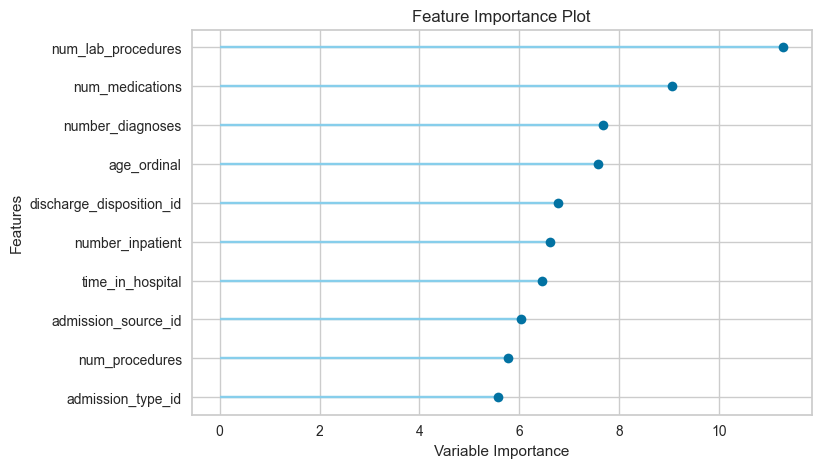

In [19]:
from pycaret.classification import get_config

transformed_feature_names = get_config("X_train_transformed").columns
catboost_estimator = tuned_model  # already the raw CatBoostClassifier, not a pipeline

feature_importance_df = (
    pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": catboost_estimator.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features (CatBoost AutoML):")
print(feature_importance_df.head(10).to_string(index=False))

plot_model(tuned_model, plot='feature')


### Comparison against baseline

In [16]:
with open(os.path.join("..", "metrics", "metrics_baseline.json")) as f:
    baseline_metrics = json.load(f)

comparison = pd.DataFrame({
    "Baseline (XGBoost, default params)": {
        "F1": baseline_metrics["f1_score"],
        "AUC-ROC": baseline_metrics["auc_roc"],
        "Accuracy": baseline_metrics["accuracy"],
        "Precision": baseline_metrics["precision"],
        "Recall": baseline_metrics["recall"],
    },
    "AutoML (CatBoost, PyCaret)": {
        "F1": metrics_automl["f1_score"],
        "AUC-ROC": metrics_automl["auc_roc"],
        "Accuracy": metrics_automl["accuracy"],
        "Precision": metrics_automl["precision"],
        "Recall": metrics_automl["recall"],
    },
})
comparison["Delta (AutoML - Baseline)"] = (
    comparison["AutoML (CatBoost, PyCaret)"] - comparison["Baseline (XGBoost, default params)"]
)
print(comparison.round(4))


           Baseline (XGBoost, default params)  AutoML (CatBoost, PyCaret)  \
F1                                      0.436                      0.4323   
AUC-ROC                                 0.648                      0.6574   
Accuracy                                0.625                      0.6361   
Precision                               0.563                      0.5931   
Recall                                  0.355                      0.3401   

           Delta (AutoML - Baseline)  
F1                           -0.0037  
AUC-ROC                       0.0094  
Accuracy                      0.0111  
Precision                     0.0301  
Recall                       -0.0149  
